In [1]:
# Cell 1
import numpy as np
from scipy.linalg import svd, rq
from scipy.sparse.linalg import LinearOperator, eigsh
import matplotlib.pyplot as plt
import os

# Create directory for figures as requested
os.makedirs("figureAKLT", exist_ok=True)

print("Running Phase 0: Index Convention Tests...")

# 1. MPS storage order
A_test = np.random.rand(3, 2, 4) + 1j * np.random.rand(3, 2, 4)
assert A_test.shape == (3, 2, 4)

# 2. MPO physical index order (Input=0 -> Output=1 for S^+)
Sp_test = np.array([[0, 1], [0, 0]], dtype=complex)
W_test = np.zeros((5, 5, 2, 2), dtype=complex)
W_test[1, 0, :, :] = Sp_test
assert W_test[1, 0, 0, 1] == 1.0  
assert W_test[1, 0, 1, 0] == 0.0  

# 3. Complex conjugation (NO Transpose)
A_conj = A_test.conj()
assert A_conj.shape == A_test.shape
assert np.allclose(A_conj[1, 0, 2], np.conj(A_test[1, 0, 2]))

# 4. Reshape for QR
M_test = np.random.rand(3, 2, 4)
M_mat = M_test.reshape(3 * 2, 4, order='C')
assert np.allclose(M_mat[1 * 2 + 0, 2], M_test[1, 0, 2])

# 5. Left-canonical verification
Q_test, R_test = np.linalg.qr(M_mat)
A_left = Q_test.reshape(3, 2, 4, order='C')
I_test = np.einsum('xsa,xsb->ab', A_left.conj(), A_left, optimize=True)
assert np.allclose(I_test, np.eye(4), atol=1e-14)

# 6. Environment Hermiticity
L_test = np.random.rand(5, 3, 3) + 1j * np.random.rand(5, 3, 3)
for b in range(5):
    L_test[b] = (L_test[b] + L_test[b].conj().T) / 2
    assert np.allclose(L_test[b], L_test[b].conj().T, atol=1e-14)

print("Phase 0 tests passed successfully! Index conventions verified.")

Running Phase 0: Index Convention Tests...
Phase 0 tests passed successfully! Index conventions verified.


In [2]:
# Cell 2
def truncate_bond(M, D_max, tol=1e-10, abs_tol=1e-14):
    """SVD compression with tolerance (Algorithm 3)."""
    U, S, Vh = svd(M, full_matrices=False)
    
    # Ensure descending order
    idx = np.argsort(S)[::-1]
    S, U, Vh = S[idx], U[:, idx], Vh[idx, :]
    
    if S[0] < abs_tol:
        D = 1
    else:
        D = min(D_max, np.sum(S > max(tol * S[0], abs_tol)))
        
    eta = np.sum(S[D:]**2) # Truncation error
    
    # FIX: Return S[:D] as a 1D array (not np.diag(S[:D]))
    return U[:, :D], S[:D], Vh[:D, :], eta

def right_canonicalize_mps(M_list):
    """Right-canonicalize the entire MPS using SVD sweeps (stable alternative to RQ)."""
    L = len(M_list)
    B_list = list(M_list)
    
    for i in range(L-1, 0, -1):
        D_left, d, D_right = B_list[i].shape
        # C-order reshape
        M_mat = B_list[i].reshape(D_left, d * D_right, order='C')
        U, S, Vh = svd(M_mat, full_matrices=False)
        
        # Vh is right-canonical
        B_list[i] = Vh.reshape(len(S), d, D_right, order='C')
        
        # Absorb U*S into the left site
        R = U @ np.diag(S)
        B_list[i-1] = np.einsum('xsa,ab->xsb', B_list[i-1], R, optimize=True)
        
    # Normalize the final leftmost site
    norm = np.linalg.norm(B_list[0])
    B_list[0] = B_list[0] / norm
    return B_list

In [8]:
# Cell 3
from scipy.sparse.linalg import LinearOperator, eigsh, ArpackNoConvergence

def update_left_env(L_old, A, W):
    T1 = np.einsum('bxy, xia -> byia', L_old, A)
    T2 = np.einsum('bBti, byia -> Byta', W, T1)
    L_new = np.einsum('Byta, ytA -> BaA', T2, A.conj())
    return L_new

def update_right_env(R_old, B_tensor, W):
    T1 = np.einsum('Bxy, aix -> Baiy', R_old, B_tensor)
    T2 = np.einsum('bBti, Baiy -> baty', W, T1)
    R_new = np.einsum('baty, Aty -> baA', T2, B_tensor.conj())
    return R_new

def apply_Heff(v_flat, L_env, W, R_env, Dl, d, Dr):
    v = v_flat.reshape((Dl, d, Dr), order='C')
    T1 = np.einsum('bxy, xia -> byia', L_env, v)
    T2 = np.einsum('bBti, byia -> Byta', W, T1)
    Hv = np.einsum('BaA, Byta -> ytA', R_env, T2)
    return Hv.reshape(-1, order='C')

def apply_Heff_2site(v_flat, L_env, W1, W2, R_env, Dl, d1, d2, Dr):
    v = v_flat.reshape((Dl, d1, d2, Dr), order='C')
    T1 = np.einsum('bxy, xija -> byija', L_env, v)
    T2 = np.einsum('bBti, byija -> Bytja', W1, T1)
    T3 = np.einsum('BCpj, Bytja -> Cypta', W2, T2)
    Hv = np.einsum('CaA, Cypta -> ytpA', R_env, T3)
    return Hv.reshape(-1, order='C')

def solve_eigenproblem(matvec, dim, v0=None):
    if dim <= 800:
        H_mat = np.zeros((dim, dim), dtype=complex)
        for i in range(dim):
            e = np.zeros(dim, dtype=complex)
            e[i] = 1.0
            H_mat[:, i] = matvec(e)
            
        H_mat = (H_mat + H_mat.conj().T) / 2.0 
        E, V = np.linalg.eigh(H_mat)
        return E[0], V[:, 0]
    else:
        Heff_op = LinearOperator((dim, dim), matvec=matvec, dtype=complex)
        
        if v0 is not None:
            v0 = v0 / np.linalg.norm(v0)
            # CRITICAL FIX: Always inject microscopic noise to protect against 
            # perfectly exact zero-residuals and perfectly degenerate states
            v0 += 1e-12 * (np.random.rand(dim) - 0.5 + 1j * (np.random.rand(dim) - 0.5))
            v0 /= np.linalg.norm(v0)
            
        try:
            E, V = eigsh(Heff_op, k=1, which='SA', tol=1e-8, maxiter=500, ncv=20, v0=v0)
            return E[0].real, V[:, 0]
        except ArpackNoConvergence as e:
            # If it hits max iteration limit, gracefully return the best converged state
            return e.eigenvalues[0].real, e.eigenvectors[:, 0]

In [4]:
# Cell 4
def get_heisenberg_mpo(L, J=1.0, Jz=1.0, h=0.0):
    """Construct Heisenberg MPO for spin-1/2 chain."""
    d, D_W = 2, 5
    Sp = np.array([[0., 1.], [0., 0.]], dtype=complex)
    Sm = np.array([[0., 0.], [1., 0.]], dtype=complex)
    Sz = np.array([[0.5, 0.], [0., -0.5]], dtype=complex)
    Id = np.eye(2, dtype=complex)
    
    W = []
    # Left boundary (shape: 1 x D_W x d x d)
    W0 = np.zeros((1, D_W, d, d), dtype=complex)
    W0[0, 0] = -h * Sz
    W0[0, 1], W0[0, 2] = (J/2) * Sm, (J/2) * Sp
    W0[0, 3], W0[0, 4] = Jz * Sz, Id
    W.append(W0)
    
    # Bulk
    for _ in range(1, L-1):
        Wi = np.zeros((D_W, D_W, d, d), dtype=complex)
        Wi[0, 0], Wi[1, 0], Wi[2, 0], Wi[3, 0], Wi[4, 0] = Id, Sp, Sm, Sz, -h * Sz
        Wi[4, 1], Wi[4, 2] = (J/2) * Sm, (J/2) * Sp
        Wi[4, 3], Wi[4, 4] = Jz * Sz, Id
        W.append(Wi)
        
    # Right boundary (shape: D_W x 1 x d x d)
    WL = np.zeros((D_W, 1, d, d), dtype=complex)
    WL[0, 0], WL[1, 0], WL[2, 0], WL[3, 0], WL[4, 0] = Id, Sp, Sm, Sz, -h * Sz
    W.append(WL)
    
    return W


def get_aklt_mpo(L):
    """Construct AKLT MPO using robust SVD."""
    d = 3
    Sz = np.array([[1, 0, 0], [0, 0, 0], [0, 0, -1]], dtype=complex)
    Sp = np.array([[0, np.sqrt(2), 0], [0, 0, np.sqrt(2)], [0, 0, 0]], dtype=complex)
    Sm = Sp.conj().T
    Id = np.eye(3, dtype=complex)
    
    # Local 2-site Hamiltonian H_local = S.S + 1/3 (S.S)^2
    SS = (np.kron(Sz, Sz) + 0.5 * (np.kron(Sp, Sm) + np.kron(Sm, Sp)))
    H_local = SS + (1.0/3.0) * np.linalg.matrix_power(SS, 2)
    
    # Convert H_local to MPO format using SVD
    H_mat = H_local.reshape((d, d, d, d)).transpose((0, 2, 1, 3)).reshape((d*d, d*d))
    U, S, Vh = svd(H_mat, full_matrices=False)
    
    K = np.sum(S > 1e-13)
    
    # CRITICAL FIX: [:, None] forces broadcasting over rows (the bond index) instead of columns
    U_scaled = U[:, :K] * np.sqrt(S[:K])
    Vh_scaled = Vh[:K, :] * np.sqrt(S[:K])[:, None]
    
    Op1 = U_scaled.reshape((d, d, K)).transpose((2, 0, 1))
    Op2 = Vh_scaled.reshape((K, d, d))
    
    D_W = K + 2
    W = []
    
    # Left boundary
    W0 = np.zeros((1, D_W, d, d), dtype=complex)
    for k in range(K): W0[0, k+1] = Op1[k]
    W0[0, -1] = Id
    W.append(W0)
    
    # Bulk
    for _ in range(1, L-1):
        Wi = np.zeros((D_W, D_W, d, d), dtype=complex)
        Wi[0, 0], Wi[-1, -1] = Id, Id
        for k in range(K):
            Wi[-1, k+1], Wi[k+1, 0] = Op1[k], Op2[k]
        W.append(Wi)
        
    # Right boundary
    WL = np.zeros((D_W, 1, d, d), dtype=complex)
    WL[0, 0] = Id
    for k in range(K): WL[k+1, 0] = Op2[k]
    W.append(WL)
    
    return W

In [5]:
# Cell 5
def run_dmrg_singlesite(W, D_max=50, max_sweeps=10, tol_energy=1e-8):
    L = len(W)
    d = W[0].shape[2]
    
    # 1. Initialize random MPS
    M_list = []
    D_curr = 1
    for i in range(L):
        D_next = min(D_curr * d, d**(L-i-1), D_max)
        M_list.append(np.random.rand(D_curr, d, max(D_next, 1)) + 
                      1j * np.random.rand(D_curr, d, max(D_next, 1)))
        D_curr = max(D_next, 1)
        
    M_list = right_canonicalize_mps(M_list)
    
    # 2. Initialize environments
    L_env, R_env = [None] * L, [None] * L
    
    L_env[0] = np.zeros((W[0].shape[0], 1, 1), dtype=complex)
    L_env[0][-1, 0, 0] = 1.0 # b_left
    
    R_env[L-1] = np.zeros((W[-1].shape[1], 1, 1), dtype=complex)
    R_env[L-1][0, 0, 0] = 1.0 # b_right
    
    for i in range(L-1, 0, -1):
        R_env[i-1] = update_right_env(R_env[i], M_list[i], W[i])
        
    energy_prev = 1e10
    energies = []
    
    for sweep in range(max_sweeps):
        # --- Right sweep ---
        for i in range(L-1):
            Dl, d_phys, Dr = M_list[i].shape
            
            Heff_op = LinearOperator((Dl*d_phys*Dr, Dl*d_phys*Dr), 
                                     matvec=lambda v: apply_Heff(v, L_env[i], W[i], R_env[i], Dl, d_phys, Dr),
                                     dtype=complex)
            
            E, vecs = eigsh(Heff_op, k=1, which='SA', tol=1e-10, v0=M_list[i].flatten(order='C'))
            
            U, S, Vh, _ = truncate_bond(vecs[:, 0].reshape(Dl * d_phys, Dr, order='C'), D_max)
            M_list[i] = U.reshape(Dl, d_phys, len(S), order='C')
            
            # Absorb singular values into next site
            M_list[i+1] = np.einsum('ab,bsc->asc', np.diag(S) @ Vh, M_list[i+1], optimize=True)
            L_env[i+1] = update_left_env(L_env[i], M_list[i], W[i])
            
        # --- Left sweep ---
        for i in range(L-1, 0, -1):
            Dl, d_phys, Dr = M_list[i].shape
            
            Heff_op = LinearOperator((Dl*d_phys*Dr, Dl*d_phys*Dr), 
                                     matvec=lambda v: apply_Heff(v, L_env[i], W[i], R_env[i], Dl, d_phys, Dr),
                                     dtype=complex)
            
            E, vecs = eigsh(Heff_op, k=1, which='SA', tol=1e-10, v0=M_list[i].flatten(order='C'))
            
            U, S, Vh, _ = truncate_bond(vecs[:, 0].reshape(Dl, d_phys * Dr, order='C'), D_max)
            M_list[i] = Vh.reshape(len(S), d_phys, Dr, order='C')
            
            # Absorb into left site
            M_list[i-1] = np.einsum('xsa,ab->xsb', M_list[i-1], U @ np.diag(S), optimize=True)
            R_env[i-1] = update_right_env(R_env[i], M_list[i], W[i])
            
        dE = np.abs(E[0].real - energy_prev)
        energies.append(E[0].real)
        print(f"Sweep {sweep+1:02d}/{max_sweeps} | Energy: {E[0].real:.10f} | dE: {dE:.2e}")
        
        if dE < tol_energy * L:
            print("Converged!")
            break
        energy_prev = E[0].real
        
    return E[0].real, energies

In [9]:
# Cell 8
def truncate_bond(M, D_max, abs_tol=1e-12):
    U, S, Vh = svd(M, full_matrices=False)
    idx = np.argsort(S)[::-1]
    S, U, Vh = S[idx], U[:, idx], Vh[idx, :]
    D = min(D_max, np.sum(S > abs_tol))
    if D == 0: D = 1
    eta = np.sum(S[D:]**2)
    return U[:, :D], S[:D], Vh[:D, :], eta

def run_dmrg_twosite(W, D_max=50, max_sweeps=10, tol_energy=1e-10):
    L = len(W)
    d = W[0].shape[2]
    
    M_list = []
    D_curr = 1
    for i in range(L):
        D_next = min(D_curr * d, d**(L-i-1), D_max)
        M_list.append((np.random.rand(D_curr, d, max(D_next, 1)) - 0.5) + 
                      1j * (np.random.rand(D_curr, d, max(D_next, 1)) - 0.5))
        D_curr = max(D_next, 1)
        
    M_list = right_canonicalize_mps(M_list)
    
    L_env, R_env = [None] * L, [None] * L
    L_env[0] = np.zeros((W[0].shape[0], 1, 1), dtype=complex)
    L_env[0][-1, 0, 0] = 1.0 
    R_env[L-1] = np.zeros((W[-1].shape[1], 1, 1), dtype=complex)
    R_env[L-1][0, 0, 0] = 1.0 
    
    for i in range(L-1, 0, -1):
        R_env[i-1] = update_right_env(R_env[i], M_list[i], W[i])
        
    energy_prev = 1e10
    energies = []
    
    for sweep in range(max_sweeps):
        noise_amp = 1e-4 if sweep < max_sweeps - 3 else 0.0
        
        for i in range(L-1):
            Dl, d1, _ = M_list[i].shape
            _, d2, Dr = M_list[i+1].shape
            dim = Dl * d1 * d2 * Dr
            
            Theta = np.tensordot(M_list[i], M_list[i+1], axes=([2], [0]))
            
            matvec = lambda v: apply_Heff_2site(v, L_env[i], W[i], W[i+1], R_env[i+1], Dl, d1, d2, Dr)
            E, vecs = solve_eigenproblem(matvec, dim, v0=Theta.flatten(order='C'))
            
            Theta_mat = vecs.reshape(Dl * d1, d2 * Dr, order='C')
            if noise_amp > 0:
                Theta_mat += noise_amp * (np.random.rand(*Theta_mat.shape) - 0.5 + 1j * (np.random.rand(*Theta_mat.shape) - 0.5))
                
            U, S, Vh, _ = truncate_bond(Theta_mat, D_max)
            S = S / np.linalg.norm(S)
            
            M_list[i] = U.reshape(Dl, d1, len(S), order='C')
            M_list[i+1] = np.einsum('ab,bsc->asc', np.diag(S), Vh.reshape(len(S), d2, Dr, order='C'), optimize=True)
            L_env[i+1] = update_left_env(L_env[i], M_list[i], W[i])
            
        for i in range(L-2, -1, -1):
            Dl, d1, _ = M_list[i].shape
            _, d2, Dr = M_list[i+1].shape
            dim = Dl * d1 * d2 * Dr
            
            Theta = np.tensordot(M_list[i], M_list[i+1], axes=([2], [0]))
            
            matvec = lambda v: apply_Heff_2site(v, L_env[i], W[i], W[i+1], R_env[i+1], Dl, d1, d2, Dr)
            E, vecs = solve_eigenproblem(matvec, dim, v0=Theta.flatten(order='C'))
            
            Theta_mat = vecs.reshape(Dl * d1, d2 * Dr, order='C')
            if noise_amp > 0:
                Theta_mat += noise_amp * (np.random.rand(*Theta_mat.shape) - 0.5 + 1j * (np.random.rand(*Theta_mat.shape) - 0.5))
                
            U, S, Vh, _ = truncate_bond(Theta_mat, D_max)
            S = S / np.linalg.norm(S)
            
            M_list[i+1] = Vh.reshape(len(S), d2, Dr, order='C')
            M_list[i] = np.einsum('xsa,ab->xsb', U.reshape(Dl, d1, len(S), order='C'), np.diag(S), optimize=True)
            R_env[i] = update_right_env(R_env[i+1], M_list[i+1], W[i+1])
            
        dE = np.abs(E - energy_prev)
        energies.append(E)
        current_max_D = max(m.shape[2] for m in M_list)
        print(f"Sweep {sweep+1:02d}/{max_sweeps} | Energy: {E:.10f} | dE: {dE:.2e} | Max D: {current_max_D}")
        
        if dE < tol_energy * L and noise_amp == 0.0:
            print("Converged!")
            break
        energy_prev = E
        
    return E, energies

--- Running Two-Site DMRG for Small Heisenberg (L=8, D_max=20) ---
Sweep 01/5 | Energy: -3.3749312808 | dE: 1.00e+10 | Max D: 16
Sweep 02/5 | Energy: -3.3749311632 | dE: 1.18e-07 | Max D: 16
Sweep 03/5 | Energy: -3.3749325987 | dE: 1.44e-06 | Max D: 16
Sweep 04/5 | Energy: -3.3749325987 | dE: 2.22e-15 | Max D: 16
Converged!

Completed in 2.25 seconds.
Final Energy (Heisenberg L=8): -3.3749325987
Exact Reference Value:            -3.3749321091
Error:                            4.90e-07

--- Running Two-Site DMRG for Small AKLT (L=8, D_max=20) ---
Sweep 01/5 | Energy: -4.6666641867 | dE: 1.00e+10 | Max D: 20
Sweep 02/5 | Energy: -4.6666642759 | dE: 8.92e-08 | Max D: 20
Sweep 03/5 | Energy: -4.6666666667 | dE: 2.39e-06 | Max D: 20
Sweep 04/5 | Energy: -4.6666666667 | dE: 2.66e-15 | Max D: 2
Converged!

Completed in 24.95 seconds.
Final Energy (AKLT L=8): -4.6666666667
Exact Reference Value:       -4.6666666667
Error:                       6.22e-15


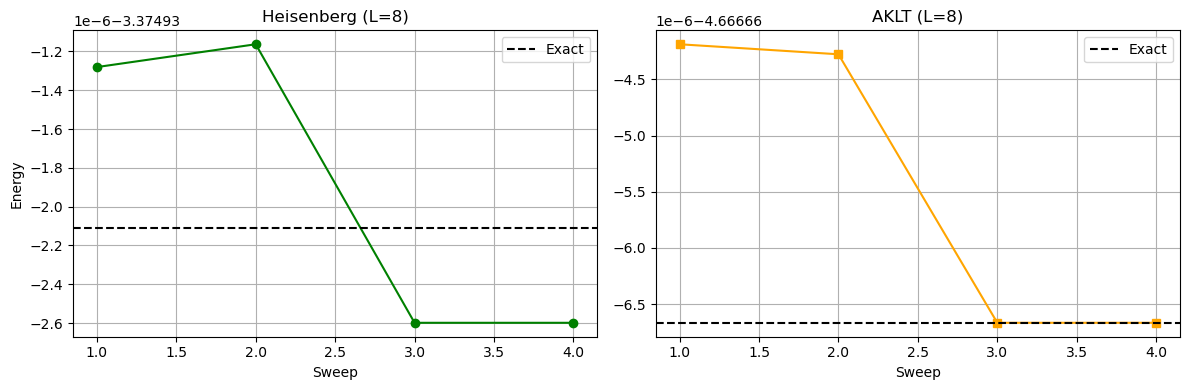

In [10]:
# Cell 10
import time

# --- 1. Small Heisenberg Model (L=8) ---
L_small = 8
D_max_small = 20  # D=16 is enough for exact L=8

print(f"--- Running Two-Site DMRG for Small Heisenberg (L={L_small}, D_max={D_max_small}) ---")
W_small = get_heisenberg_mpo(L_small)

start_time = time.time()
E0_small, E_hist_small = run_dmrg_twosite(W_small, D_max=D_max_small, max_sweeps=5)
end_time = time.time()

exact_L8 = -3.374932109083  # From Section 11.3 of your note

print(f"\nCompleted in {end_time - start_time:.2f} seconds.")
print(f"Final Energy (Heisenberg L={L_small}): {E0_small:.10f}")
print(f"Exact Reference Value:            {exact_L8:.10f}")
print(f"Error:                            {abs(E0_small - exact_L8):.2e}\n")


# --- 2. Small AKLT Model (L=8) ---
print(f"--- Running Two-Site DMRG for Small AKLT (L={L_small}, D_max={D_max_small}) ---")
W_aklt_small = get_aklt_mpo(L_small)

start_time = time.time()
E0_aklt, E_hist_aklt = run_dmrg_twosite(W_aklt_small, D_max=D_max_small, max_sweeps=5)
end_time = time.time()

exact_aklt = -(L_small - 1) * (2/3)

print(f"\nCompleted in {end_time - start_time:.2f} seconds.")
print(f"Final Energy (AKLT L={L_small}): {E0_aklt:.10f}")
print(f"Exact Reference Value:       {exact_aklt:.10f}")
print(f"Error:                       {abs(E0_aklt - exact_aklt):.2e}")

# Plotting both
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(range(1, len(E_hist_small)+1), E_hist_small, marker='o', color='green')
ax1.axhline(exact_L8, color='black', linestyle='--', label='Exact')
ax1.set_title(f'Heisenberg (L={L_small})')
ax1.set_xlabel('Sweep')
ax1.set_ylabel('Energy')
ax1.legend()
ax1.grid(True)

ax2.plot(range(1, len(E_hist_aklt)+1), E_hist_aklt, marker='s', color='orange')
ax2.axhline(exact_aklt, color='black', linestyle='--', label='Exact')
ax2.set_title(f'AKLT (L={L_small})')
ax2.set_xlabel('Sweep')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('figureAKLT/small_systems_verification.png')
plt.show()